# 08 — Pairs execution and risk controls

This notebook tests *execution choices*, not new pairs. It keeps the top-11 pair book fixed and uses only days **1–700**: the score comparison is on validation days **501–700**. Days 701–1000 remain untouched.

## Controls tested

Each configuration changes one execution choice from the equal-dollar baseline: beta refit frequency, a maximum holding period, an adverse z-score stop, or beta-hedged sizing. Compare score *and* drawdown/turnover; do not select a setting from a single metric.

In [1]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DISCOVERY_END = 500
VALIDATION_END = 700
LOOKBACK_DAYS = 250
ENTRY_Z = 0.50
EXIT_Z = 0.10
DOLLAR_LIMIT = 10_000

repo_root = next((path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'backtester').exists()), None)
if repo_root is None:
    raise FileNotFoundError('Run this notebook from inside the project directory.')
sys.path.insert(0, str(repo_root / 'backtester'))
from backtest.engine import run_backtest
from backtest.metrics import compute_metrics

price_frame = pd.read_csv(repo_root / 'backtester' / 'data' / '2026' / 'prices.txt', sep=r'\s+', nrows=VALIDATION_END)
prices = price_frame.to_numpy(dtype=float).T

def load_strategy(filename, module_name):
    spec = importlib.util.spec_from_file_location(module_name, repo_root / 'src' / 'strategies' / filename)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

baseline_module = load_strategy('pairs_top_11_equal_dollar_rolling.py', 'top_11_reference')
PAIRS = tuple(baseline_module.PAIRS)
assert all(0 not in pair[:2] for pair in PAIRS)
print(f'{len(PAIRS)} fixed non-ALGO pairs; validation days {DISCOVERY_END + 1}–{VALIDATION_END}.')

11 fixed non-ALGO pairs; validation days 501–700.


## 1. Controlled strategy variants

The strategy always uses the same rolling spread signal. `refit_every` controls how often the regression is refreshed; a time stop or z-stop closes an open pair before the ordinary mean-reversion exit.

In [2]:
class PairsExecutionStrategy:
    def __init__(self, *, sizing='equal_dollar', refit_every=1, max_hold=0, stop_z=None):
        self.sizing = sizing
        self.refit_every = refit_every
        self.max_hold = max_hold
        self.stop_z = stop_z
        self.reset_state()

    def reset_state(self):
        self.state = np.zeros(len(PAIRS), dtype=int)
        self.holding_days = np.zeros(len(PAIRS), dtype=int)
        self.parameters = [None] * len(PAIRS)
        self.last_history_length = None

    def _fit(self, window, a, b):
        log_a, log_b = np.log(window[a]), np.log(window[b])
        beta, intercept = np.polyfit(log_b, log_a, 1)
        spread = log_a - (intercept + beta * log_b)
        return beta, intercept, spread.mean(), spread.std()

    def __call__(self, prc_so_far):
        history = np.asarray(prc_so_far, dtype=float)
        n_inst, n_days = history.shape
        if self.last_history_length is not None and n_days != self.last_history_length + 1:
            self.reset_state()
        self.last_history_length = n_days
        if n_days < LOOKBACK_DAYS or np.any(history <= 0) or not np.all(np.isfinite(history)):
            return np.zeros(n_inst, dtype=int)

        window, current = history[:, -LOOKBACK_DAYS:], history[:, -1]
        target = np.zeros(n_inst, dtype=int)
        refresh = (n_days % self.refit_every == 0)
        for i, (a, b, *_) in enumerate(PAIRS):
            if refresh or self.parameters[i] is None:
                self.parameters[i] = self._fit(window, a, b)
            beta, intercept, mean, std = self.parameters[i]
            if std < 1e-12:
                self.state[i] = self.holding_days[i] = 0
                continue

            z = (np.log(current[a]) - (intercept + beta * np.log(current[b])) - mean) / std
            previous, next_state = self.state[i], self.state[i]
            if previous == 0:
                next_state = 1 if z < -ENTRY_Z else (-1 if z > ENTRY_Z else 0)
            elif previous == 1 and (z > -EXIT_Z or (self.stop_z is not None and z < -self.stop_z)):
                next_state = 0
            elif previous == -1 and (z < EXIT_Z or (self.stop_z is not None and z > self.stop_z)):
                next_state = 0
            if previous != 0 and self.max_hold and self.holding_days[i] >= self.max_hold:
                next_state = 0

            self.holding_days[i] = 0 if next_state == 0 else (1 if previous == 0 else self.holding_days[i] + 1)
            self.state[i] = next_state
            if next_state == 0:
                continue
            if self.sizing == 'equal_dollar':
                target[a] += int(next_state * DOLLAR_LIMIT / current[a])
                target[b] += int(-next_state * DOLLAR_LIMIT / current[b])
            elif self.sizing == 'beta_hedged':
                units = np.array([1.0, -beta])
                scale = min(DOLLAR_LIMIT / (abs(units[0]) * current[a]), DOLLAR_LIMIT / (abs(units[1]) * current[b]))
                target[a] += int(np.round(next_state * scale * units[0]))
                target[b] += int(np.round(next_state * scale * units[1]))
            else:
                raise ValueError('sizing must be equal_dollar or beta_hedged')

        limits = (DOLLAR_LIMIT / current).astype(int)
        target = np.clip(target, -limits, limits).astype(int)
        target[0] = 0
        return target

## 2. Validation comparison

These are controlled one-change comparisons against the baseline. They are diagnostic evidence, not a license to combine every apparent winner.

,configuration,score,mean_pl,ann_sharpe,max_drawdown,hit_rate,turnover,mean_gross_exposure,mean_abs_net_exposure
0,"Baseline: equal dollar, daily refit",399.45,$405.89,7.88,"$-2,501",71.0%,"$7,655,117","$172,328",$736
2,"Equal dollar, 10-day refit",398.17,$404.49,7.94,"$-2,151",73.0%,"$7,457,806","$173,036",$725
1,"Equal dollar, 5-day refit",392.37,$398.85,7.78,"$-2,501",71.5%,"$7,576,733","$172,626",$729
3,"Equal dollar, 20-day time stop",391.87,$398.50,7.69,"$-2,370",70.0%,"$8,437,342","$169,439",$732
4,"Equal dollar, 2.5σ adverse stop",381.16,$387.67,7.65,"$-2,389",69.5%,"$8,668,843","$169,737",$719
5,"Beta hedged, daily refit",349.28,$354.76,7.98,"$-2,586",70.0%,"$6,376,063","$143,467","$7,731"


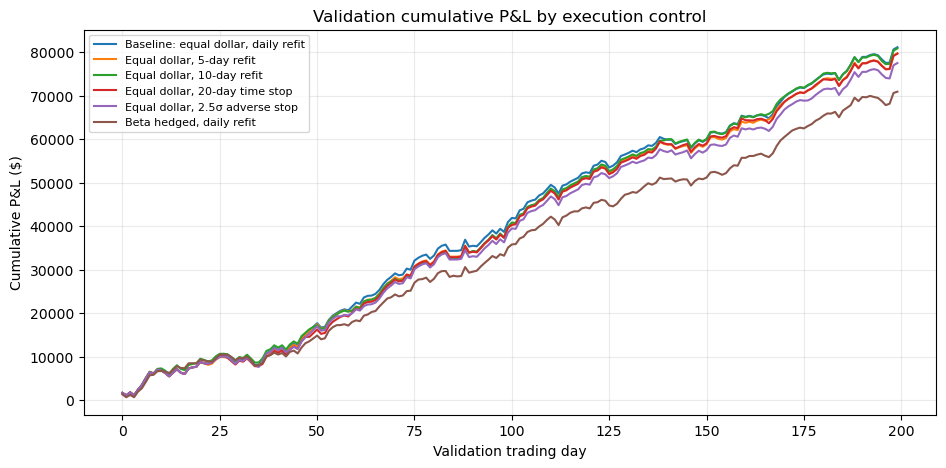

In [3]:
CONFIGURATIONS = [
    ('Baseline: equal dollar, daily refit', dict(sizing='equal_dollar', refit_every=1)),
    ('Equal dollar, 5-day refit', dict(sizing='equal_dollar', refit_every=5)),
    ('Equal dollar, 10-day refit', dict(sizing='equal_dollar', refit_every=10)),
    ('Equal dollar, 20-day time stop', dict(sizing='equal_dollar', refit_every=1, max_hold=20)),
    ('Equal dollar, 2.5σ adverse stop', dict(sizing='equal_dollar', refit_every=1, stop_z=2.5)),
    ('Beta hedged, daily refit', dict(sizing='beta_hedged', refit_every=1)),
]

runs = []
for label, kwargs in CONFIGURATIONS:
    strategy = PairsExecutionStrategy(**kwargs)
    result = run_backtest(prices, strategy, eval_start=DISCOVERY_END, eval_end=VALIDATION_END)
    metrics = compute_metrics(result)
    gross = (np.abs(result.positions_held) * result.prices).sum(axis=1)
    net = (result.positions_held * result.prices).sum(axis=1)
    runs.append({
        'configuration': label, 'result': result, 'daily_pl': result.daily_pl,
        'score': metrics['score'], 'mean_pl': metrics['mean_pl'], 'ann_sharpe': metrics['ann_sharpe'],
        'max_drawdown': metrics['max_drawdown'], 'hit_rate': metrics['hit_rate'],
        'turnover': metrics['total_dvolume'], 'mean_gross_exposure': gross.mean(),
        'mean_abs_net_exposure': np.abs(net).mean(),
    })

comparison = pd.DataFrame([{key: value for key, value in run.items() if key not in {'result', 'daily_pl'}} for run in runs]).sort_values('score', ascending=False)
display(comparison.style.format({
    'score': '{:.2f}', 'mean_pl': '${:,.2f}', 'ann_sharpe': '{:.2f}', 'max_drawdown': '${:,.0f}',
    'hit_rate': '{:.1%}', 'turnover': '${:,.0f}', 'mean_gross_exposure': '${:,.0f}', 'mean_abs_net_exposure': '${:,.0f}',
}).set_caption('Top-11 pairs: validation-only execution-control comparison'))

plt.figure(figsize=(11, 5))
for run in runs:
    plt.plot(np.cumsum(run['daily_pl']), label=run['configuration'], linewidth=1.5)
plt.title('Validation cumulative P&L by execution control')
plt.xlabel('Validation trading day')
plt.ylabel('Cumulative P&L ($)')
plt.grid(alpha=0.25)
plt.legend(fontsize=8)
plt.show()

### Interpretation

Prefer a control only if its improvement is meaningful and it does not create an unacceptable drawdown, turnover, or net-exposure trade-off. A configuration that merely wins by a tiny amount on this 200-day validation window is not strong enough evidence to replace the baseline.

## 3. Decision discipline

After choosing at most one or two well-supported changes here, freeze them before evaluating days 701–1000. Do not use the final test result to return and retune this notebook.